# Retail Data Wrangling and Analytics

In [0]:
# Import modules 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [0]:
from pyspark.sql.types import *
from pyspark.sql.functions import *
orderSchema = StructType([
    StructField("invoice_no", StringType()),
    StructField("stock_code", StringType()),
    StructField("description", StringType()),
    StructField("quantity", IntegerType()),
    StructField("invoice_date", DateType()),
    StructField("unit_price", FloatType()),
    StructField("customer_id", FloatType()),
    StructField("country", StringType()),
])
df = spark.read.load('/data/*.csv', format='csv', header=True, schema=orderSchema)
display(df.head(10))

invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01,6.949999809265137,13085.0,United Kingdom
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01,6.75,13085.0,United Kingdom
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01,6.75,13085.0,United Kingdom
489434,22041,"""RECORD FRAME 7"""" SINGLE SIZE """,48,2009-12-01,2.0999999046325684,13085.0,United Kingdom
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01,1.25,13085.0,United Kingdom
489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01,1.649999976158142,13085.0,United Kingdom
489434,21871,SAVE THE PLANET MUG,24,2009-12-01,1.25,13085.0,United Kingdom
489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01,5.949999809265137,13085.0,United Kingdom
489435,22350,CAT BOWL,12,2009-12-01,2.549999952316284,13085.0,United Kingdom
489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01,3.75,13085.0,United Kingdom


# Total Invoice Amount Distribution

---

Minimum:0.00
Mean:20.13
Median:9.96
Mode:15.00
Maximum:168469.59



invoice_total
83.39999389648438
81.0
81.0
100.79999542236328
30.0
39.599998474121094
30.0
59.5
30.599998474121094
45.0


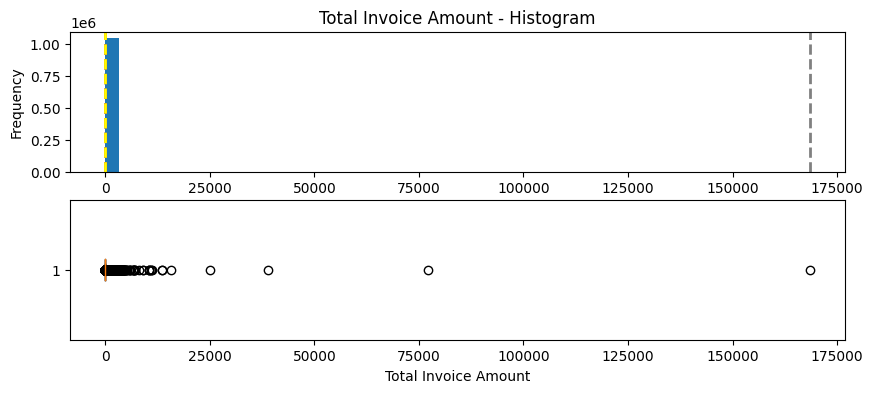

In [0]:
import matplotlib.pyplot as plt# Step 1: Calculate total invoice amount

df_total = df.withColumn("invoice_total", df["quantity"] * df["unit_price"] )

#display(df_total)
invoice_total_sum = df_total.groupBy().sum("invoice_total").toPandas()


# Step 2: draw distribution of invoice amount
def show_distribution(col, label="Data Distribution"):
    var = col

    # Get statistics
    min_val = var.min()
    max_val = var.max()
    mean_val = var.mean()
    med_val = var.median()
    mod_val = var.mode()[0]

    print('Minimum:{:.2f}\nMean:{:.2f}\nMedian:{:.2f}\nMode:{:.2f}\nMaximum:{:.2f}\n'.format(min_val,
                                                                                            mean_val,
                                                                                            med_val,
                                                                                            mod_val,
                                                                                            max_val))

    # Create a Figure
    fig, (ax, bx) = plt.subplots(2,1,figsize=(10,4))

    # Add lines for the statistics
    ax.axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
    ax.axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    ax.axvline(x=med_val, color = 'red', linestyle='dashed', linewidth = 2)
    ax.axvline(x=mod_val, color = 'yellow', linestyle='dashed', linewidth = 2)
    ax.axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)

    # Add titles and labels
    ax.hist(var, bins=50)
    ax.set_title(f"{label} - Histogram")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")

    bx.boxplot(var, vert=False)
    bx.set_xlabel(label)

    # Show the figure
    fig.show()

clean_data = df_total.filter(df_total['invoice_total'] > 0)
show_distribution(clean_data.select('invoice_total').toPandas()['invoice_total'], label="Total Invoice Amount")
display(clean_data.select('invoice_total').head(10))

Minimum:0.00
Mean:8.98
Median:7.62
Mode:15.00
Maximum:24.75



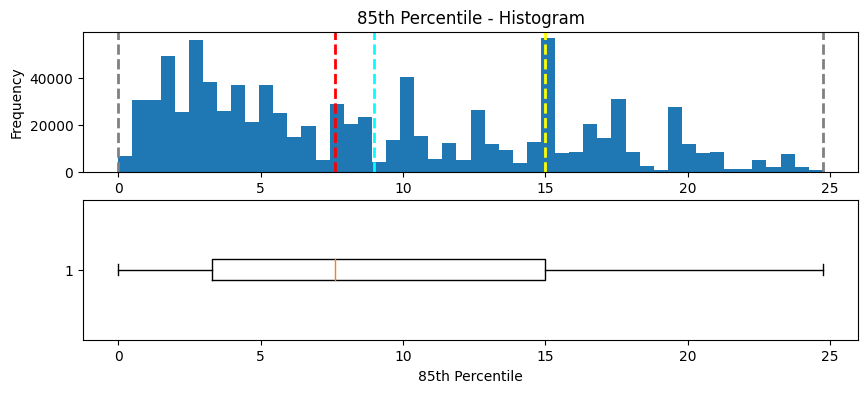

In [0]:
# draw the distribution for the first 85 quantiles
q85 = clean_data.approxQuantile('invoice_total', [0.85], 0.01)
col = clean_data.filter(clean_data['invoice_total'] <= q85[0])
show_distribution(col.select('invoice_total').toPandas()['invoice_total'], label='85th Percentile')

# Monthly Placed and Canceled Orders

---

In [0]:
# Grab date data
dt_df = df.withColumn(
    "invoice_ym",
    concat_ws('', year(df['invoice_date']).cast(StringType()), month(df['invoice_date']).cast(StringType()))
)

# Find cancelled orders (invoice_no delimited with C)
dt_df = dt_df.withColumn(
    "cancelled",
    dt_df['invoice_no'].contains('C')
)

# Drop the duplicates of every order to get real order number
dt_df_clean = dt_df.dropDuplicates(['invoice_no']).groupBy('invoice_ym').agg(count('*').alias('fufilled_count'))

# Create a df of only cancelled orders and drop duplicates to grab total cancelled orders.
dt_df_cancelled = dt_df.filter(dt_df['cancelled'] == True).dropDuplicates(['invoice_no']).groupBy('invoice_ym').agg(count('*').alias('cancelled_count'))

# Create a df to hold fufilled and cancelled orders
dt_monthly_orders_df = dt_df_clean.join(
    dt_df_cancelled,
    on='invoice_ym',
    how='left'
).withColumn(
    'monthly_orders', 
    dt_df_clean['fufilled_count'] - dt_df_cancelled['cancelled_count']
)
display(dt_monthly_orders_df.select('invoice_ym', 'monthly_orders'))

invoice_ym,monthly_orders
20111,1216
20117,1657
201010,2489
20107,1673
201110,2275
20101,1333
20118,1459
201012,1699
201011,3093
20102,1729


<Axes: >

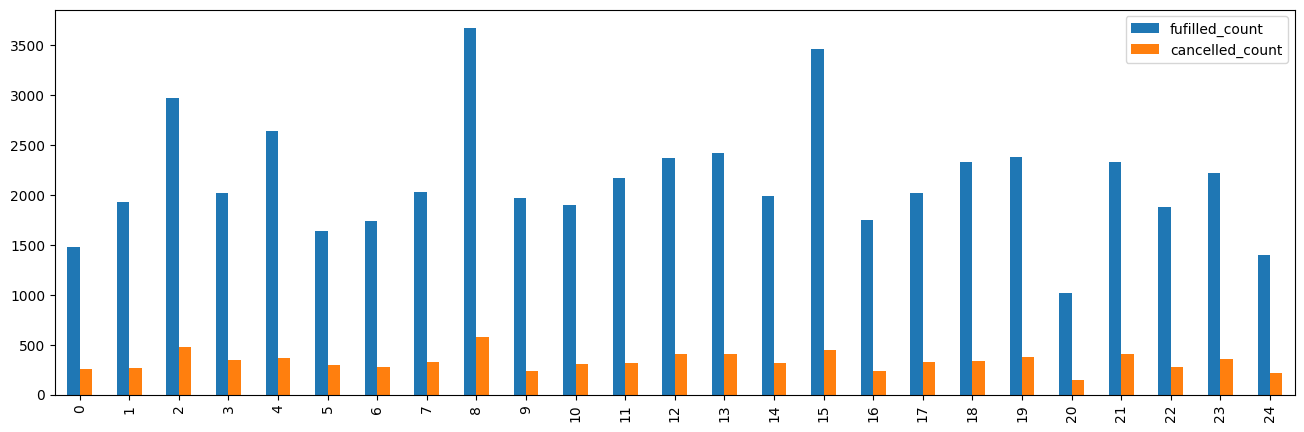

In [0]:
dt_monthly_orders_df.toPandas().plot(
    y=['fufilled_count', 'cancelled_count'], 
    kind='bar', 
    figsize=(16,5)
)

# Monthly Sales

---

In [0]:
# Essentially, we have to find the sales value per month
retail_df = dt_df.withColumn(
    "invoice_total",
    dt_df['quantity'] * dt_df['unit_price']
)
monthly_sales = retail_df.groupby('invoice_ym').agg(sum('invoice_total').alias('invoice_total'))
monthly_sales
display(monthly_sales)

invoice_ym,invoice_total
20107,575236.3596651554
20101,624032.8896515106
20102,533091.424455221
20104,590580.4300854017
20103,765848.757825097
20105,615322.8286303803
200912,799847.1075055711
20106,679786.6077747606
201010,1045168.3482284844
201012,1126445.4675593823


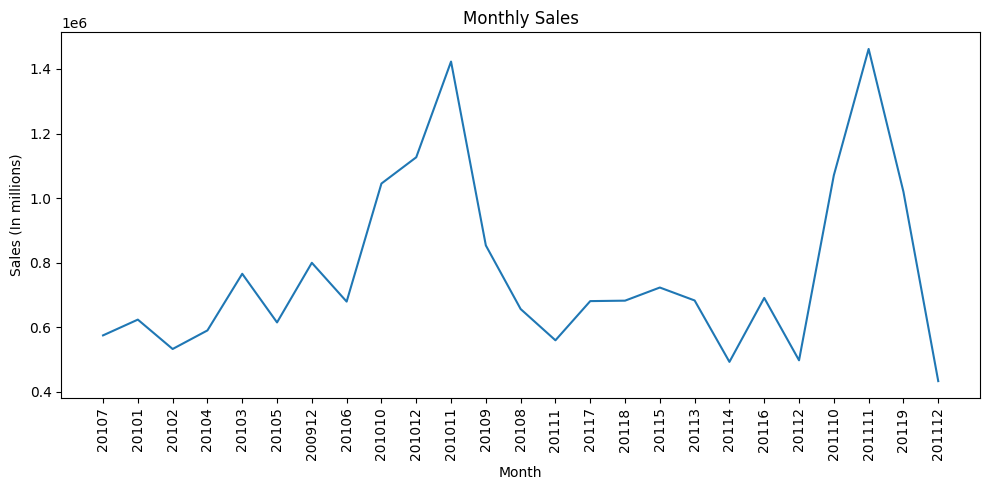

In [0]:
ax = monthly_sales.toPandas().plot(
    x='invoice_ym',
    y='invoice_total', 
    kind='line',
    figsize=(10,5),
    legend=False
)

ax.set_title("Monthly Sales")
ax.set_xlabel("Month")
ax.set_ylabel("Sales (In millions)")

ax.set_xticks(range(len(monthly_sales.toPandas())))
ax.set_xticklabels(monthly_sales.toPandas()['invoice_ym'], rotation=90)
plt.tight_layout() 

plt.show()

# Monthly Sales Growth


---

In [0]:
from pyspark.sql.window import Window
# Find the percent
monthly_sales_growth = monthly_sales
monthly_sales_growth = monthly_sales_growth.withColumn(
    "growth",
    (monthly_sales_growth['invoice_total'] - lag('invoice_total').over(Window.orderBy('invoice_ym'))) / lag('invoice_total').over(Window.orderBy('invoice_ym')),
)
display(monthly_sales_growth)


invoice_ym,invoice_total,growth
200912,799847.1075055711,null
20101,624032.8896515106,-0.2198097813997982
201010,1045168.3482284844,0.6748609978107976
201011,1422654.6372941246,0.3611727141426195
201012,1126445.4675593823,-0.208208768291178
20102,533091.424455221,-0.5267490173223869
20103,765848.757825097,0.43661804090684114
20104,590580.4300854017,-0.22885501340686726
20105,615322.8286303803,0.041895053212990266
20106,679786.6077747606,0.104764159795383


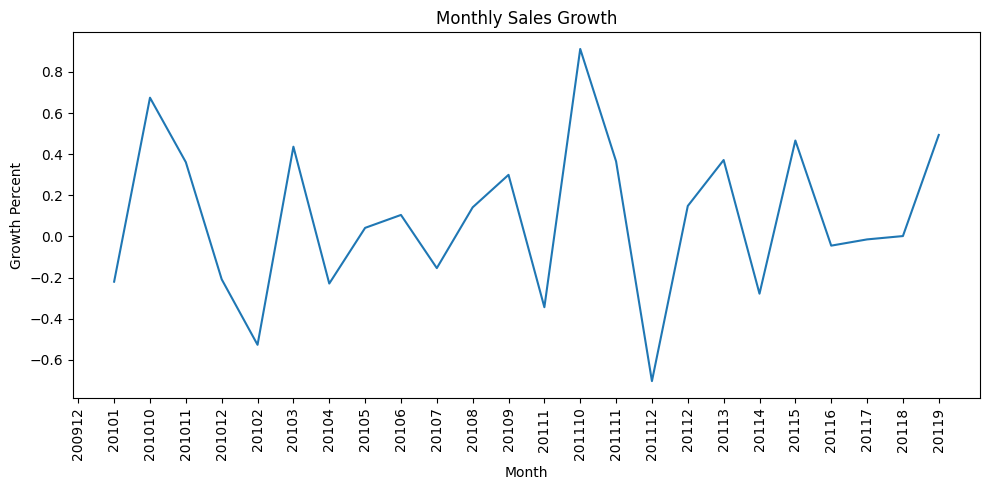

In [0]:
ax = monthly_sales_growth.toPandas().plot(
    x='invoice_ym',
    y='growth',
    kind='line',
    xlabel="Month",
    ylabel="Growth Percent",
    title="Monthly Sales Growth",
    figsize=(10,5),
    legend=False,
)
ax.set_xticks(range(len(monthly_sales_growth.toPandas())))
ax.set_xticklabels(monthly_sales_growth.toPandas()['invoice_ym'], rotation=90)
plt.tight_layout() 

plt.show()


# Monthly Active Users

---


In [0]:
# Find unique cust_ids
unique_cust = retail_df.drop_duplicates(['customer_id'])
# Create unique cust count
unique_cust_count = unique_cust.groupby('invoice_ym').agg({'customer_id':'count'})
display(unique_cust_count)

invoice_ym,count(customer_id)
20117,102
20111,71
201010,379
20107,183
201110,221
20101,394
20118,106
201012,77
201011,322
20102,363


<Axes: xlabel='Year Month', ylabel='# of active users'>

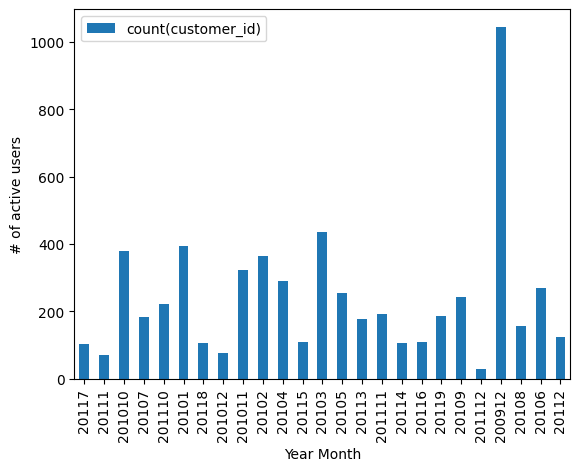

In [0]:
unique_cust_count.toPandas().plot(
    xlabel="Year Month",
    ylabel="# of active users",
    kind='bar',
    x="invoice_ym",
    y="count(customer_id)"
)

# New and Existing Users



---


In [0]:
# Find users with their given purchase dates
first_purchase = retail_df.groupby('customer_id').agg({"invoice_ym":'min'}).withColumnRenamed('min(invoice_ym)', 'first_invoice')

unique_months = retail_df
unique_months = retail_df.join(first_purchase, on='customer_id', how='left')

unique_months = unique_months.withColumn(
    'user_type',
    when(unique_months['invoice_ym'] == unique_months['first_invoice'], 'new').otherwise('existing')
)

user_counts = unique_months.groupby(['invoice_ym', 'user_type']).agg({'customer_id': 'collect_set'}).withColumnRenamed('collect_set(customer_id)', 'count')
user_counts = user_counts.withColumn('count', array_size('count'))
existing_users = user_counts
new_users = user_counts
existing_users = existing_users.filter(existing_users['user_type'] == 'existing').withColumnRenamed('count', 'existing').withColumnRenamed('user_type', 'user_type1')
new_users = new_users.filter(new_users['user_type'] == 'new').withColumnRenamed('count', 'new').withColumnRenamed('user_type', 'user_type2')

user_counts_final = existing_users.join(new_users, on='invoice_ym', how='inner').orderBy('invoice_ym')
display(user_counts_final)

invoice_ym,user_type1,existing,user_type2,new
200912,existing,0,new,1045
20101,existing,392,new,394
201010,existing,586,new,991
201011,existing,1017,new,666
201012,existing,808,new,140
20102,existing,620,new,187
20103,existing,889,new,222
20104,existing,839,new,159
20105,existing,910,new,152
20106,existing,940,new,155


<Axes: xlabel='Year Month', ylabel='User Population Growth'>

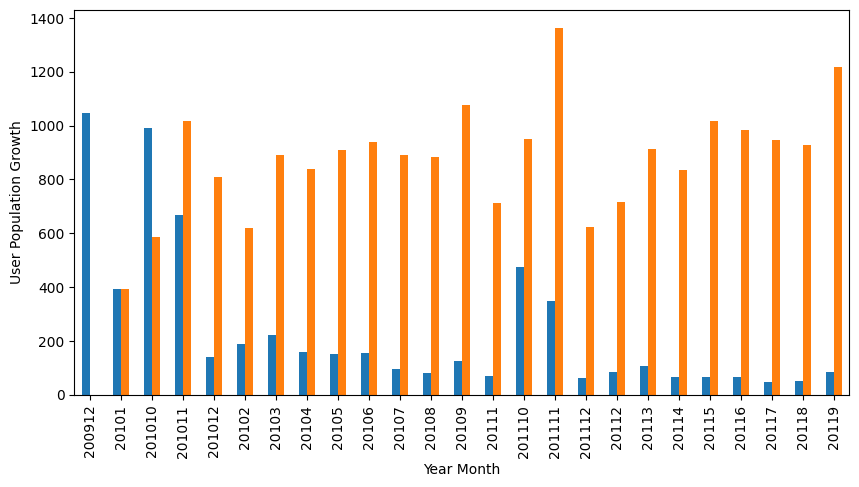

In [0]:
user_counts_final.toPandas().plot(
    x='invoice_ym',
    y=['user_type2', 'new', 'user_type1', 'existing'],
    xlabel='Year Month',
    ylabel='User Population Growth',
    legend=False,
    kind='bar',
    figsize=(10,5)
)

## Finding RFM

---

In [0]:
from pyspark.sql import functions as F
# Create reference date
snapshot = F.lit('2011-12-31').cast(DateType())
clean_retail_data = retail_df.withColumn('invoice_total', retail_df['quantity'] * retail_df['unit_price']).dropna()
display(clean_retail_data.head(10))

invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,invoice_ym,cancelled,invoice_total
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01,6.949999809265137,13085.0,United Kingdom,200912,false,83.39999389648438
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01,6.75,13085.0,United Kingdom,200912,false,81.0
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01,6.75,13085.0,United Kingdom,200912,false,81.0
489434,22041,"""RECORD FRAME 7"""" SINGLE SIZE """,48,2009-12-01,2.0999999046325684,13085.0,United Kingdom,200912,false,100.79999542236328
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01,1.25,13085.0,United Kingdom,200912,false,30.0
489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01,1.649999976158142,13085.0,United Kingdom,200912,false,39.599998474121094
489434,21871,SAVE THE PLANET MUG,24,2009-12-01,1.25,13085.0,United Kingdom,200912,false,30.0
489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01,5.949999809265137,13085.0,United Kingdom,200912,false,59.5
489435,22350,CAT BOWL,12,2009-12-01,2.549999952316284,13085.0,United Kingdom,200912,false,30.599998474121094
489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01,3.75,13085.0,United Kingdom,200912,false,45.0


In [0]:
rfm = clean_retail_data.groupBy('customer_id').agg(
    F.datediff(snapshot, F.max('invoice_date')).alias('recency'),
    F.countDistinct('invoice_no').alias('frequency'),
    F.sum('invoice_total').alias('monetary')
)

display(rfm.orderBy('customer_id').head(10))

customer_id,recency,frequency,monetary
12346.0,347,17,-64.68000209331512
12347.0,24,8,5633.3200306892395
12348.0,97,5,2019.4000129699707
12349.0,40,5,4404.539983987808
12350.0,332,1,334.39999771118164
12351.0,397,1,300.9300022125244
12352.0,58,13,1889.2099857330322
12353.0,226,2,406.760000705719
12354.0,254,1,1079.400016784668
12355.0,236,2,947.6099939346313


# RFM Segmentation

---

In [0]:
from pyspark.ml.feature import QuantileDiscretizer

discretizer_f = QuantileDiscretizer(
    numBuckets=5,
    inputCol='frequency',
    outputCol='f_score'
)

discretizer_m = QuantileDiscretizer(
    numBuckets=5,
    inputCol='monetary',
    outputCol='m_score'
)


rfm = rfm.withColumn('inverted_recency', F.col('recency') * -1)
discretizer_r = QuantileDiscretizer(
    numBuckets=5,
    inputCol='inverted_recency',
    outputCol='r_score'
)
rfm = discretizer_r.fit(rfm).transform(rfm) 
rfm = discretizer_f.fit(rfm).transform(rfm)
rfm = rfm.withColumn(
    'f_score',
    F.when(rfm['frequency'] >= 12, 4)
    .when(rfm['frequency'] >= 8, 3)
    .when(rfm['frequency'] >= 5, 2)
    .when(rfm['frequency'] >= 4, 1)
    .otherwise(0)
)
rfm = discretizer_m.fit(rfm).transform(rfm)
rfm = rfm.dropna()
rfm = rfm.withColumn('r_score', F.col('r_score') + 1)
rfm = rfm.withColumn('f_score', F.col('f_score') + 1)
rfm = rfm.withColumn('m_score', F.col('m_score') + 1)


rfm = rfm.withColumn('rfm_segment', F.concat(F.col('r_score').cast(IntegerType()).cast(StringType()), F.col('f_score').cast(IntegerType()).cast(StringType()), F.col('m_score').cast(IntegerType()).cast(StringType())))

display(rfm.orderBy('customer_id').head(10))

customer_id,recency,frequency,monetary,inverted_recency,r_score,f_score,m_score,rfm_segment
12346.0,347,17,-64.68000209331512,-347,2.0,5,1.0,251
12347.0,24,8,5633.3200306892395,-24,5.0,4,5.0,545
12348.0,97,5,2019.4000129699707,-97,3.0,3,4.0,334
12349.0,40,5,4404.539983987808,-40,5.0,3,5.0,535
12350.0,332,1,334.39999771118164,-332,2.0,1,2.0,212
12351.0,397,1,300.9300022125244,-397,2.0,1,2.0,212
12352.0,58,13,1889.2099857330322,-58,4.0,5,4.0,454
12353.0,226,2,406.760000705719,-226,2.0,1,2.0,212
12354.0,254,1,1079.400016784668,-254,2.0,1,3.0,213
12355.0,236,2,947.6099939346313,-236,2.0,1,3.0,213


In [0]:
rfm = rfm.withColumn('segment', F.concat(rfm['r_score'].cast(IntegerType()).cast(StringType()),rfm['f_score'].cast(IntegerType()).cast(StringType())))

rfm = rfm.withColumn(
    'segment',
    when(rfm['segment'].rlike(r'[1-2][1-2]'), 'Hibernating')
    .when(rfm['segment'].rlike(r'[1-2][3-4]'), 'At Risk')
    .when(rfm['segment'].rlike(r'[1-2]5'), 'Can\'t Lose')
    .when(rfm['segment'].rlike(r'3[1-2]'), 'About to Sleep')
    .when(rfm['segment'].rlike(r'33'), 'Need Attention')
    .when(rfm['segment'].rlike(r'[3-4][4-5]'), 'Loyal Customers')
    .when(rfm['segment'].rlike(r'41'), 'Promising')
    .when(rfm['segment'].rlike(r'51'), 'New Customers')
    .when(rfm['segment'].rlike(r'[4-5][2-3]'), 'Potential Loyalists')
    .when(rfm['segment'].rlike(r'5[4-5]'), 'Champions')
    .otherwise('Unknown')  # Default case if none of the patterns match
)



display(rfm.groupby('segment').count().orderBy('count'))

rfm = rfm.withColumn('r_score', F.col('r_score').cast(IntegerType()))
rfm = rfm.withColumn('f_score', F.col('f_score').cast(IntegerType()))
rfm = rfm.withColumn('m_score', F.col('m_score').cast(IntegerType()))

rfm_agg = rfm.groupBy('segment').agg(
    F.mean('recency').alias('mean_recency'),
    F.mean('frequency').alias('mean_frequency'),
    F.mean('monetary').alias('mean_monetary'),
)

display(rfm_agg)

segment,count
Can't Lose,62
Need Attention,239
New Customers,252
At Risk,347
Promising,423
Potential Loyalists,606
About to Sleep,625
Champions,684
Loyal Customers,741
Hibernating,1963


segment,mean_recency,mean_frequency,mean_monetary
Champions,29.28216374269006,27.919590643274855,12723.13781719561
Promising,58.621749408983455,1.9905437352245863,609.3998335398751
At Risk,380.78674351585016,6.599423631123919,1597.1817841399516
About to Sleep,132.2032,2.2688,705.4052838764572
Hibernating,470.18950585838,1.7896077432501274,453.56678606744157
Potential Loyalists,45.01155115511551,5.3250825082508255,1546.4565325392125
Loyal Customers,84.16734143049932,15.224021592442645,5190.010979476323
Need Attention,135.34309623430963,5.920502092050209,1736.8215017208058
New Customers,31.035714285714285,2.0793650793650795,674.3357131397204
Can't Lose,344.241935483871,20.467741935483872,7007.326269304015
